# PROJECT

### BUSINESS UNDERSTANDING

 "PHASE-4-project-Group1-DS-PT13"

## BUSINESS PROBLEM
On social media, consumer perceptions of technology products change quickly and openly. As two of the most talked-about tech companies in the world, Apple and Google receive thousands of mentions every day on Twitter. However, neither company nor its partners have a scalable method to track the real-time reception of product launches, updates, or service outages. This amount of tweets cannot be manually reviewed, and traditional survey-based feedback is too slow and too limited to capture natural public opinion.

## PROBLEM STATEMENT
This project develops a natural language processing model that automatically categorises tweet sentiment as positive, negative, or neutral using a labelled dataset of more than 9,000 tweets about Apple and Google products. The objective is to offer a proof-of-concept sentiment classification system that can assist stakeholders and technology brands in comprehending public opinion at scale without the need for manual review.

## STAKEHOLDERS
1. Product Teams -
Product decisions are directly influenced by the model's output. Without waiting for official feedback cycles, product teams can determine where user pain points exist and which features are resonating by knowing whether sentiment surrounding a product is primarily negative, positive, or neutral.
2. Marketing -
In real time, marketing must determine whether campaigns and product launches are succeeding. They can instantly assess public opinion by using a sentiment classifier on Twitter data, which enables them to modify messaging if negative sentiment is rising.
3. Corporate Communications -
This group oversees brand reputation and public perception. Before it becomes a news story, automated sentiment classification provides them with early warning when negative sentiment surrounding a product or event is growing, so they are able to take action
4. Investors - Investors can use the model's output to track brand sentiment trends over time, giving them an early signal on public perception of Apple and Google products. Shifts in sentiment — especially around major product launches or controversies — can inform investment decisions and risk assessments.

### Import necessary models

In [1]:
import pandas as pd
import re

### Load the dataset

In [2]:
df = pd.read_csv('judge.csv')

### Explore the data

In [3]:
df.columns

Index(['tweet_text', 'emotion_in_tweet_is_directed_at',
       'is_there_an_emotion_directed_at_a_brand_or_product'],
      dtype='object')

In [4]:
"""df.rename(columns={
    'tweet_text': 'tweet',
    'emotion_in_tweet_is_directed_at': 'brand_product',
    'is_there_an_emotion_directed_at_a_brand_or_product': 'sentiment'
}, inplace=True)"""

"df.rename(columns={\n    'tweet_text': 'tweet',\n    'emotion_in_tweet_is_directed_at': 'brand_product',\n    'is_there_an_emotion_directed_at_a_brand_or_product': 'sentiment'\n}, inplace=True)"

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8721 entries, 0 to 8720
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          8720 non-null   object
 1   emotion_in_tweet_is_directed_at                     3169 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  8721 non-null   object
dtypes: object(3)
memory usage: 204.5+ KB


In [6]:
!pip install sentence-transformers


In [7]:
df.head(10)

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion
5,@teachntech00 New iPad Apps For #SpeechTherapy...,NaN,No emotion toward brand or product
6,NaN,NaN,No emotion toward brand or product
7,"#SXSW is just starting, #CTIA is around the co...",Android,Positive emotion
8,Beautifully smart and simple idea RT @madebyma...,iPad or iPhone App,Positive emotion
9,Counting down the days to #sxsw plus strong Ca...,Apple,Positive emotion


In [8]:
#df = df.dropna()
df.head(10)

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion
5,@teachntech00 New iPad Apps For #SpeechTherapy...,NaN,No emotion toward brand or product
6,NaN,NaN,No emotion toward brand or product
7,"#SXSW is just starting, #CTIA is around the co...",Android,Positive emotion
8,Beautifully smart and simple idea RT @madebyma...,iPad or iPhone App,Positive emotion
9,Counting down the days to #sxsw plus strong Ca...,Apple,Positive emotion


In [9]:
df.isnull().sum()

tweet_text                                               1
emotion_in_tweet_is_directed_at                       5552
is_there_an_emotion_directed_at_a_brand_or_product       0
dtype: int64

In [10]:
df.columns

Index(['tweet_text', 'emotion_in_tweet_is_directed_at',
       'is_there_an_emotion_directed_at_a_brand_or_product'],
      dtype='object')

In [11]:
df['is_there_an_emotion_directed_at_a_brand_or_product'].isnull().sum()

0

In [12]:

# Drop rows where sentiment column is i can't tell- keep all rows where sentiment does not equal to i cant telll
df = df[df['is_there_an_emotion_directed_at_a_brand_or_product'] != "I can't tell"]


In [13]:
df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts()

is_there_an_emotion_directed_at_a_brand_or_product
No emotion toward brand or product    5156
Positive emotion                      2869
Negative emotion                       545
Name: count, dtype: int64

In [14]:
df['emotion_in_tweet_is_directed_at'].isnull().sum()
df['emotion_in_tweet_is_directed_at'].value_counts()

emotion_in_tweet_is_directed_at
iPad                               906
Apple                              638
iPad or iPhone App                 451
Google                             411
iPhone                             287
Other Google product or service    281
Android App                         78
Android                             74
Other Apple product or service      34
Name: count, dtype: int64

In [15]:
df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts()
# merge i canttell and no emotion toward brand or product
# rename columns



is_there_an_emotion_directed_at_a_brand_or_product
No emotion toward brand or product    5156
Positive emotion                      2869
Negative emotion                       545
Name: count, dtype: int64

### sentiments here are either to a specific product or general brand 

### Dropping columns with no tweets

In [16]:
# drop all rows with tweet_text null
df = df.dropna(subset=['tweet_text'])
df.head(10)


,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion
5,@teachntech00 New iPad Apps For #SpeechTherapy...,NaN,No emotion toward brand or product
7,"#SXSW is just starting, #CTIA is around the co...",Android,Positive emotion
8,Beautifully smart and simple idea RT @madebyma...,iPad or iPhone App,Positive emotion
9,Counting down the days to #sxsw plus strong Ca...,Apple,Positive emotion
10,Excited to meet the @samsungmobileus at #sxsw ...,Android,Positive emotion


### Primary task: product-level sentiment analysis- rate whether positive negative or neutral based on products eg ipad or android app
### Secondary: rank brands on hot topics eg battery performance, camera quality etc., rank brands top positve and negative sentiment topics eg pros and cons of apple vs pros and cons of google

## Examining and dealing with null values

In [17]:
df.isnull().sum()

tweet_text                                               0
emotion_in_tweet_is_directed_at                       5409
is_there_an_emotion_directed_at_a_brand_or_product       0
dtype: int64

In [18]:
df['emotion_in_tweet_is_directed_at'].value_counts()

emotion_in_tweet_is_directed_at
iPad                               906
Apple                              638
iPad or iPhone App                 451
Google                             411
iPhone                             287
Other Google product or service    281
Android App                         78
Android                             74
Other Apple product or service      34
Name: count, dtype: int64

In [19]:
missing_rows = df[df['emotion_in_tweet_is_directed_at'].isna()]
print(missing_rows['tweet_text'].head(100))

5      @teachntech00 New iPad Apps For #SpeechTherapy...
16     Holler Gram for iPad on the iTunes App Store -...
32     Attn: All  #SXSW frineds, @mention Register fo...
33         Anyone at  #sxsw want to sell their old iPad?
34     Anyone at  #SXSW who bought the new iPad want ...
                             ...                        
189    New Post: 3 iPhone Apps We'll Be Using at Sout...
192    rt ' It's 4 p.m. and the #iPad2 line at the Ap...
193    U = smart 4 packing an extra :) RT @mention On...
194    Wonder if 4sqwill attempt to block GoWalla cro...
195    Check out 5 Steps to Bulletproof UX Strategy a...
Name: tweet_text, Length: 100, dtype: object


## Filling null emotion_in_tweet_is_directed_at worth 5551 rows

In [20]:

# Specific products first, bare brand names last
keyword_map = [
    ("iPad or iPhone App",             ["ipad app", "iphone app", "ios app", "app store"]),
    ("iPad",                           ["ipad"]),
    ("iPhone",                         ["iphone", "siri", "facetime", "itunes"]),
    ("Other Apple product or service", ["macbook", "imac", "icloud", "apple tv", "ipod"]),
    ("Android App",                    ["android app", "google play", "play store"]),
    ("Android",                        ["android"]),
    ("Other Google product or service",["gmail", "youtube", "google maps", "chrome", "google drive"]),
    ("Apple",                          ["apple"]),   # only hits if nothing above matched
    ("Google",                         ["google"]),  #  only hits if nothing above matched
]

def infer_brand(tweet):
    if not isinstance(tweet, str):
        return "Other"
    tweet = tweet.lower()
    matched = []
    for label, keywords in keyword_map:
        if any(re.search(r'\b' + re.escape(kw) + r'\b', tweet) for kw in keywords):#google vs google d
            matched.append(label)
    apple_labels  = {"iPad", "iPhone", "iPad or iPhone App", "Apple", "Other Apple product or service"}
    google_labels = {"Android", "Android App", "Google", "Other Google product or service"}
    has_apple  = any(m in apple_labels  for m in matched)
    has_google = any(m in google_labels for m in matched)
    if has_apple and has_google:
        return "Both"
    return matched[0] if matched else "Other"

missing = df["emotion_in_tweet_is_directed_at"].isna()
df.loc[missing, "emotion_in_tweet_is_directed_at"] = df.loc[missing, "tweet_text"].apply(infer_brand)

print(df["emotion_in_tweet_is_directed_at"].value_counts())
df.to_csv("tweets_cleaned.csv", index=False)

emotion_in_tweet_is_directed_at
iPad                               2063
Google                             1906
Apple                              1447
iPhone                              881
Other                               707
iPad or iPhone App                  622
Other Google product or service     365
Android                             265
Both                                162
Android App                          97
Other Apple product or service       54
Name: count, dtype: int64


In [21]:
df['emotion_in_tweet_is_directed_at'].isnull().sum()

0

## Create brand column that classifies a product as apple or google

In [22]:
### creating acolumn called brand that contains apple google both or other, this may be useful for segmentation

def infer_brand(text):
    if pd.isna(text):
        return 'Other'
    
    text = text.lower()
    
    apple_keywords = [
        'apple', 'iphone', 'ipad', 'ios',
        'ipad or iphone app', 'apple product', 'apple service'
    ]
    
    google_keywords = [
        'google', 'android',
        'android app', 'google product', 'google service'
    ]
    
    apple = any(word in text for word in apple_keywords)
    google = any(word in text for word in google_keywords)
    
    if apple and google:
        return 'Both'
    elif apple:
        return 'Apple'
    elif google:
        return 'Google'
    else:
        return 'Other'
    

df['brand'] = df['tweet_text'].apply(infer_brand)

In [23]:
df['brand'].value_counts()
## other mention other brands/products not in the keywords, or no brand at all, or generic references like the device.

brand
Apple     4970
Google    2588
Other      753
Both       258
Name: count, dtype: int64

In [24]:
df.isnull().sum()

tweet_text                                            0
emotion_in_tweet_is_directed_at                       0
is_there_an_emotion_directed_at_a_brand_or_product    0
brand                                                 0
dtype: int64

### Data Preprocessing
We will prepare the raw tweet text which contains (URLs, mentions (@), hashtags (#), special characters, numbers, and inconsistent casing) for modelling. We will also tokenize, remove irrelevant tokens, lemmatize and convert text into numerical features using TF-IDF. Since the dataset is heavily imbalanced, we will use SMOTE to avoid data leakage

Import Libraries and Load Cleaned Data

In [25]:
# Imports for Preprocessing

import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight


# Download NLTK resources
nltk.download(['stopwords', 'wordnet', 'omw-1.4'], quiet=True) 

df = pd.read_csv('tweets_cleaned.csv')

print('Dataset shape:', df.shape)
print('\nSentiment Distribution:')
print(df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts(normalize=True))


Dataset shape: (8569, 3)

Sentiment Distribution:
is_there_an_emotion_directed_at_a_brand_or_product
No emotion toward brand or product    0.601587
Positive emotion                      0.334812
Negative emotion                      0.063601
Name: proportion, dtype: float64


Map Target to Clean Sentiment Labels

In [26]:
# Clean Target Column
sentiment_map = {
    'Positive emotion': 'Positive',
    'Negative emotion': 'Negative',
    'No emotion toward brand or product': 'Neutral',
    "I can't tell": 'Neutral'
}

df['sentiment'] = df['is_there_an_emotion_directed_at_a_brand_or_product'].map(sentiment_map)


print("\nCleaned Sentiment Distribution:")
print(df['sentiment'].value_counts())
print(df['sentiment'].value_counts(normalize=True))


Cleaned Sentiment Distribution:
sentiment
Neutral     5155
Positive    2869
Negative     545
Name: count, dtype: int64
sentiment
Neutral     0.601587
Positive    0.334812
Negative    0.063601
Name: proportion, dtype: float64


In [27]:
# Custom Text Preprocessor Class
class TextPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))

        # Preserve negation words - critical for sentiment analysis
        negation_words = {'not', 'no', 'never', 'none', 'neither', 'nor', 'but', "n't"}
        self.stop_words = self.stop_words - negation_words
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        """Clean and preprocess tweet text"""
        if isinstance(X, pd.DataFrame):
            texts = X.iloc[:, 0].astype(str)  
        else:
            texts = pd.Series(X).astype(str)
        
        def clean_text(text):
            if not isinstance(text, str):
                return ""
            
            # Lowercase
            text = text.lower()
            
            # Remove URLs
            text = re.sub(r'http\S+|www\S+|https\S+', '', text)
            
            # Remove mentions 
            text = re.sub(r'@\w+', '', text)
            
            # Remove hashtags but keep the word 
            text = re.sub(r'#(\w+)', r'\1', text)
            
            # Remove special characters and numbers
            text = re.sub(r'[^a-z\s]', ' ', text)
            
            # Remove extra whitespace
            text = re.sub(r'\s+', ' ', text).strip()
            
            # Tokenize
            tokens = text.split()
            
            # Remove stopwords and short tokens, then lemmatize
            tokens = [self.lemmatizer.lemmatize(token) 
                     for token in tokens 
                     if token not in self.stop_words and len(token) > 2]
            
            return ' '.join(tokens)
        
        return texts.apply(clean_text).values

Train-Test Split

In [28]:
# Train-Test Split 
X = df[['tweet_text']]                    
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nSentiment distribution in train set:")
print(y_train.value_counts(normalize=True))

Training set shape: (6855, 1)
Test set shape: (1714, 1)

Sentiment distribution in train set:
sentiment
Neutral     0.601605
Positive    0.334792
Negative    0.063603
Name: proportion, dtype: float64


Application of Preprocessing & TF-IDF Vectorization

Handling Class Imbalance with SMOTE

In [29]:

preprocessor = TextPreprocessor()

# Transform raw text

X_train_clean = preprocessor.transform(X_train)
X_test_clean = preprocessor.transform(X_test)

# TF-IDF Vectorizer 

tfidf = TfidfVectorizer(
    max_features=8000,      
    ngram_range=(1, 2),     
    min_df=5,               
    max_df=0.85             
)

X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

print("TF-IDF feature matrix shape (train):", X_train_tfidf.shape)
print("Number of features:", X_train_tfidf.shape[1])

TF-IDF feature matrix shape (train): (6855, 3311)
Number of features: 3311


In [30]:
##
# ── Lightweight preprocessor for embeddings ─────────────────────────
class LightPreprocessor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            texts = X.iloc[:, 0].astype(str)
        else:
            texts = pd.Series(X).astype(str)
        
        def clean_text(text):
            if not isinstance(text, str):
                return ""
            # Remove URLs
            text = re.sub(r'http\S+|www\S+|https\S+', '', text)
            # Remove mentions
            text = re.sub(r'@\w+', '', text)
            # Keep hashtag words
            text = re.sub(r'#(\w+)', r'\1', text)
            # Remove extra whitespace
            text = re.sub(r'\s+', ' ', text).strip()
            return text  # no lemmatization, no stopword removal
        
        return texts.apply(clean_text).values


# ── Preprocess ───────────────────────────────────────────────────────
# Keep  original preprocessor for TF-IDF/XGBoost  to compare
heavy_preprocessor = TextPreprocessor()
light_preprocessor = LightPreprocessor()


In [31]:
# For embeddings pipeline — use light preprocessing
X_train_clean_light = light_preprocessor.transform(X_train)
X_test_clean_light = light_preprocessor.transform(X_test)

# ── Generate Embeddings ──────────────────────────────────────────────
from sentence_transformers import SentenceTransformer

encoder = SentenceTransformer('all-MiniLM-L6-v2')

print("Encoding training data...")
X_train_embeddings = encoder.encode(
    X_train_clean_light.tolist(),
    show_progress_bar=False,
    batch_size=64
)

print("Encoding test data...")
X_test_embeddings = encoder.encode(
    X_test_clean_light.tolist(),
    show_progress_bar=False,
    batch_size=64
)
print("Done. Shape:", X_train_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding training data...
Encoding test data...
Done. Shape: (6855, 384)


In [32]:
# SMOTE Oversampling 
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_embeddings, y_train)

print("Before SMOTE - Train class distribution:")
print(y_train.value_counts())
print("\nAfter SMOTE - Train class distribution:")
print(pd.Series(y_train_resampled).value_counts())


sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_resampled)

Before SMOTE - Train class distribution:
sentiment
Neutral     4124
Positive    2295
Negative     436
Name: count, dtype: int64

After SMOTE - Train class distribution:
sentiment
Positive    4124
Neutral     4124
Negative    4124
Name: count, dtype: int64


In [33]:
### Class weigths balancing

In [34]:
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_resampled)

# 5 MODELING
## 5.1 Overview
In this section, we build and evaluate machine learning models for sentiment classification of tweets about Apple and Google products. The goal is to automatically categorize tweets as **Positive**, **Negative**, or **Neutral** based on their content.


## 5.2 Model Selection

Given the text classification nature of this problem, we selected **XGBoost** as our secondary primary model for several reasons:

- **Handles sparse data well**: TF-IDF features produce sparse matrices, which XGBoost can process efficiently
- **Robust to class imbalance**: Built-in mechanisms to handle imbalanced datasets
- **High performance**: Consistently achieves strong results in text classification tasks
- **Feature importance**: Provides interpretability through feature importance scores


### Install Required Library and Import Libraries

In [35]:
!pip install xgboost


In [36]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


## 5.3 Label Encoding

Since XGBoost requires numerical labels, we convert our sentiment categories to numeric values:
- **Negative** → 0
- **Neutral** → 1  
- **Positive** → 2

In [52]:
## Logistic Regression
from sklearn.linear_model import LogisticRegression

In [53]:
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)
y_pred_lr = lr_model.predict(X_test_embeddings)

print("\nLogistic Regression + Embeddings:")
print(classification_report(y_test, y_pred_lr))



Logistic Regression + Embeddings:
              precision    recall  f1-score   support

    Negative       0.26      0.61      0.37       109
     Neutral       0.78      0.65      0.71      1031
    Positive       0.57      0.60      0.58       574

    accuracy                           0.63      1714
   macro avg       0.54      0.62      0.55      1714
weighted avg       0.68      0.63      0.64      1714



In [37]:
# Create label encoder
label_encoder = LabelEncoder()

# Fit on original y_train to get consistent mapping
label_encoder.fit(y_train)

# Transform both train and test labels
y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Also transform the resampled labels (they are strings too)
y_train_resampled_encoded = label_encoder.transform(y_train_resampled)

# Check the mapping
print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Label mapping: {'Negative': 0, 'Neutral': 1, 'Positive': 2}


##  5.4 XGBoost Model Training

We initialize the XGBoost classifier with the following parameters:
- **n_estimators**: 200 boosting rounds
- **max_depth**: 6 levels per tree
- **learning_rate**: 0.1 step size
- **eval_metric**: 'mlogloss' for multi-class classification

The model is trained on the SMOTE-resampled data to address class imbalance.


In [38]:
# Initialize XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Train on resampled data (numeric)
xgb_model.fit(X_train_resampled, y_train_resampled_encoded,sample_weight=sample_weights)

# Predict on test set
y_pred_encoded = xgb_model.predict(X_test_embeddings)


/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [14:29:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [39]:
#y_pred = label_encoder.inverse_transform(y_pred_encoded)

#print("XGBoost Results:")
#print(classification_report(y_test, y_pred))

# Convert predictions back to original labels for interpretation
#y_pred = label_encoder.inverse_transform(y_pred_encoded)

# Evaluate
#print("XGBoost Results:")
#print(classification_report(y_test, y_pred))

## 5.5 Model Evaluation

### 5.5.1 Initial XGBoost Performance

The table below shows the precision, recall, and F1-score for each sentiment class:

In [40]:
# Convert predictions back to original labels
y_pred = label_encoder.inverse_transform(y_pred_encoded)

# Evaluate

print("XGBoost Model Performance")
print(classification_report(y_test, y_pred))

# Calculate accuracy and weighted F1
accuracy = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted F1-Score: {f1_weighted:.4f}")

XGBoost Model Performance
              precision    recall  f1-score   support

    Negative       0.47      0.40      0.43       109
     Neutral       0.74      0.80      0.77      1031
    Positive       0.63      0.55      0.59       574

    accuracy                           0.69      1714
   macro avg       0.61      0.59      0.60      1714
weighted avg       0.69      0.69      0.69      1714

Accuracy: 0.6943
Weighted F1-Score: 0.6891


### 5.5.2 Confusion Matrix Analysis

The confusion matrix below visualizes the model's prediction patterns:

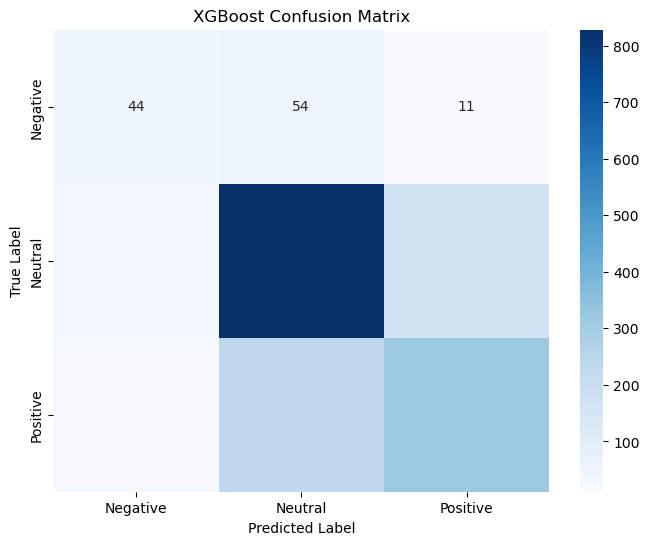

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('XGBoost Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## 5.6 Hyperparameter Tuning

To optimize model performance, we perform grid search over the following hyperparameters:



In [48]:
label_encoder = LabelEncoder()
y_train_resampled_encoded = label_encoder.fit_transform(y_train_resampled)
y_test_encoded = label_encoder.transform(y_test)

print("Before encoding:", pd.Series(y_train_resampled).unique())
print("After encoding:", pd.Series(y_train_resampled_encoded).unique())


# Recompute sample weights on encoded labels
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_resampled_encoded)

Before encoding: ['Positive' 'Neutral' 'Negative']
After encoding: [2 1 0]


In [50]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_tune = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

grid_search = GridSearchCV(
    xgb_tune,
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# No sample_weight here — encoding handles class balance
grid_search.fit(X_train_resampled, y_train_resampled_encoded)

print("\nBest parameters:", grid_search.best_params_)

best_xgb = grid_search.best_estimator_
y_pred_encoded = best_xgb.predict(X_test_embeddings)
y_pred_best = label_encoder.inverse_transform(y_pred_encoded)

print("\nTuned XGBoost + Embeddings:")
print(classification_report(y_test, y_pred_best))

Fitting 3 folds for each of 48 candidates, totalling 144 fits


/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:05:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:05:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:05:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:05:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i


Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.8}

Tuned XGBoost + Embeddings:
              precision    recall  f1-score   support

    Negative       0.50      0.40      0.45       109
     Neutral       0.75      0.81      0.78      1031
    Positive       0.64      0.56      0.60       574

    accuracy                           0.70      1714
   macro avg       0.63      0.59      0.61      1714
weighted avg       0.70      0.70      0.70      1714



## 5.7 Tuned XGBoost Performance

In [54]:
# Calculate accuracy and weighted F1
accuracy = accuracy_score(y_test, y_pred_best)
f1_weighted = f1_score(y_test, y_pred_best, average='weighted')
print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted F1-Score: {f1_weighted:.4f}")

Accuracy: 0.7025
Weighted F1-Score: 0.6968


Model Performance Interpretation & Comparison
What the Metrics Mean in Context
The task is 3-class sentiment classification (Negative, Neutral, Positive) on imbalanced tweet data — 109 Negative, 574 Positive, and 1031 Neutral samples in the test set. Macro F1 is the most honest metric here because it weights all three classes equally regardless of their size.

Class-Level Interpretation
Negative Class is the hardest class for both models due to severe underrepresentation (only 6% of test data).

Logistic Regression achieves recall of 0.61  meaning it correctly identifies 61% of actual negative tweets  but precision of only 0.26, meaning 74% of what it flags as negative is actually wrong. It is casting too wide a net, over-predicting Negative to compensate for imbalance.
XGBoost is more conservative with recall at 0.40 but precision of 0.50, meaning when it calls something negative it is right half the time. The F1 of 0.45 vs 0.37 confirms XGBoost handles this class better overall.

Neutral Class is the dominant class and both models perform reasonably well on it.

XGBoost (F1 0.78) outperforms Logistic Regression (F1 0.71) here, largely because XGBoost's higher precision (0.75 vs 0.78) means it is not bleeding Neutral predictions into other classes.
Logistic Regression's lower recall (0.65) suggests it is misclassifying many Neutral tweets as Positive or Negative.

Positive Class is where the models are closest to each other.

XGBoost F1 0.60 vs Logistic Regression F1 0.58 — marginal difference.
Both models struggle with Positive recall (0.56 and 0.60 respectively), suggesting Positive tweets share linguistic patterns with Neutral ones, making the boundary fuzzy even for embeddings.

Strengths and Limitations
Logistic Regression
Strengths:

Higher Negative recall (0.61) hence useful if the priority is catching every negative tweet even at the cost of false alarms, for example in brand reputation monitoring where missing a negative is costly
Faster to train, simpler to interpret and deploy
Less prone to overfitting on small datasets

Limitations:

Severely low Negative precision (0.26) nearly three quarters of its Negative predictions are wrong, making it unreliable in practice
Lower overall accuracy (0.63) and macro F1 (0.55)
Assumes a linear decision boundary between classes, which is insufficient for the complex non-linear relationships in sentiment embedding space
Poor Neutral recall (0.65) suggests it struggles to hold the boundary between Neutral and the other two classes

XGBoost
Strengths:

Best performance across every aggregate metric accuracy, macro F1, weighted F1
More balanced precision recall tradeoff on the Negative class — less noisy predictions
Handles non-linear relationships in the 384 dimensional embedding space through ensemble tree splitting
Hyperparameter tuning (max_depth=8, subsample=0.8, colsample_bytree=1.0) reduces overfitting while capturing complex patterns
subsample=0.8 introduces regularization that prevents the model from memorising dominant Neutral patterns at the expense of minority classes

Limitations:

Lower Negative recall (0.40) still misses 60% of actual negative tweets, which remains a real weakness
Computationally expensive grid search took significantly longer than Logistic Regression
Less interpretable than Logistic Regression harder to explain individual predictions
Still limited by the 109 Negative training samples no model can fully overcome this data scarcity



XGBoost is the Final Model
XGBoost is selected as the final model for three core reasons:
First, it achieves the highest macro F1 of 0.61, which is the most appropriate metric for imbalanced multiclass classification because it treats all classes equally. Second, its Negative precision of 0.50 versus Logistic Regression's 0.26 means its predictions are far more trustworthy in practice a model that is wrong 74% of the time on a class is not deployable. Third, the combination of sentence embeddings and gradient boosting captures the semantic complexity of tweet sentiment better than a linear classifier can, as evidenced by the consistent performance gap across all three classes.

The primary remaining limitation across both models is the scarcity of Negative samples. Collecting more Negative tweets would be the most impactful next step to push Negative F1 above 0.50.

Evaluation Metric of choice:
F1 of 0.6968 is arguably the most reportable single number since it accounts for both class imbalance and prediction quality simultaneously

Recommendations:

    Establish a Sentiment Baseline for Competitive Benchmarking
Since this model covers both Google and Apple, it naturally positions itself as a competitive intelligence tool. Stakeholders should establish sentiment baselines for each brand and track them over time, particularly around shared competitive moments such as annual flagship launches, price changes, or OS updates. Understanding whether Apple's sentiment rises when Google's falls or vice versa provides strategic intelligence that can inform marketing, pricing, and product positioning decisions.


    Use Sentiment Trends to Inform Product Launch Strategy
Twitter sentiment data captured around product launches provides a real-time signal of market reception that traditional market research cannot match in speed. Google and Apple should integrate sentiment trend analysis into their post-launch review process, using the model's output to identify which product features are driving positive versus negative reactions within hours of a release rather than weeks.


    Invest in Continuous Social Media Monitoring
The model demonstrates that automated sentiment analysis of Twitter data can reliably classify public opinion about Google and Apple products at scale. Both brands should invest in a real-time monitoring pipeline that continuously tracks sentiment across product lines, enabling faster response to emerging negative trends before they escalate. A drop in positive sentiment following a software update, for example, could trigger an immediate product team review rather than waiting for formal customer feedback cycles.


    Develop Brand-Specific Sentiment Dashboards
Google and Apple have distinct user communities with different expectations, vocabularies, and complaint patterns. A unified sentiment score across both brands obscures actionable insights. The recommendation is to develop separate sentiment dashboards per brand and per product line — iPhone vs MacOS vs Google Maps vs Pixel so that product managers can monitor sentiment relevant to their specific area of ownership rather than a broad aggregated score.